In [1]:
import pandas as pd

from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = [
    'llava_1_5_7b',
    'llava_next_llama_8b',
    'chameleon_7b',
    'paligemma_3b_224',
    'paligemma_3b_mix_224'
]

benchmarks = [
    'imagenet1k_1000',
    'imagenet1k_512',
    'imagenet1k_256',
    'imagenet1k_128',
    'imagenet1k_64',
    'imagenet1k_32',
    'imagenet1k_16',
    'imagenet1k_8',
    'imagenet1k_4',
    'imagenet1k_2',
]

outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = {
    'llava_1_5_7b': 'LLaVA 1.5 7B',
    'llava_next_llama_8b': 'Llava Next Llama 3 8B',
    'chameleon_7b': 'Chameleon 7B',
    'paligemma_3b_224': 'Paligemma 3B 224',
    'paligemma_3b_mix_224': 'Paligemma 3B Mix 224',
}
results['model_name'] = results["model_name"].map(model_mappings)

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_3451477/3272649302.py:33: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.lineplot(


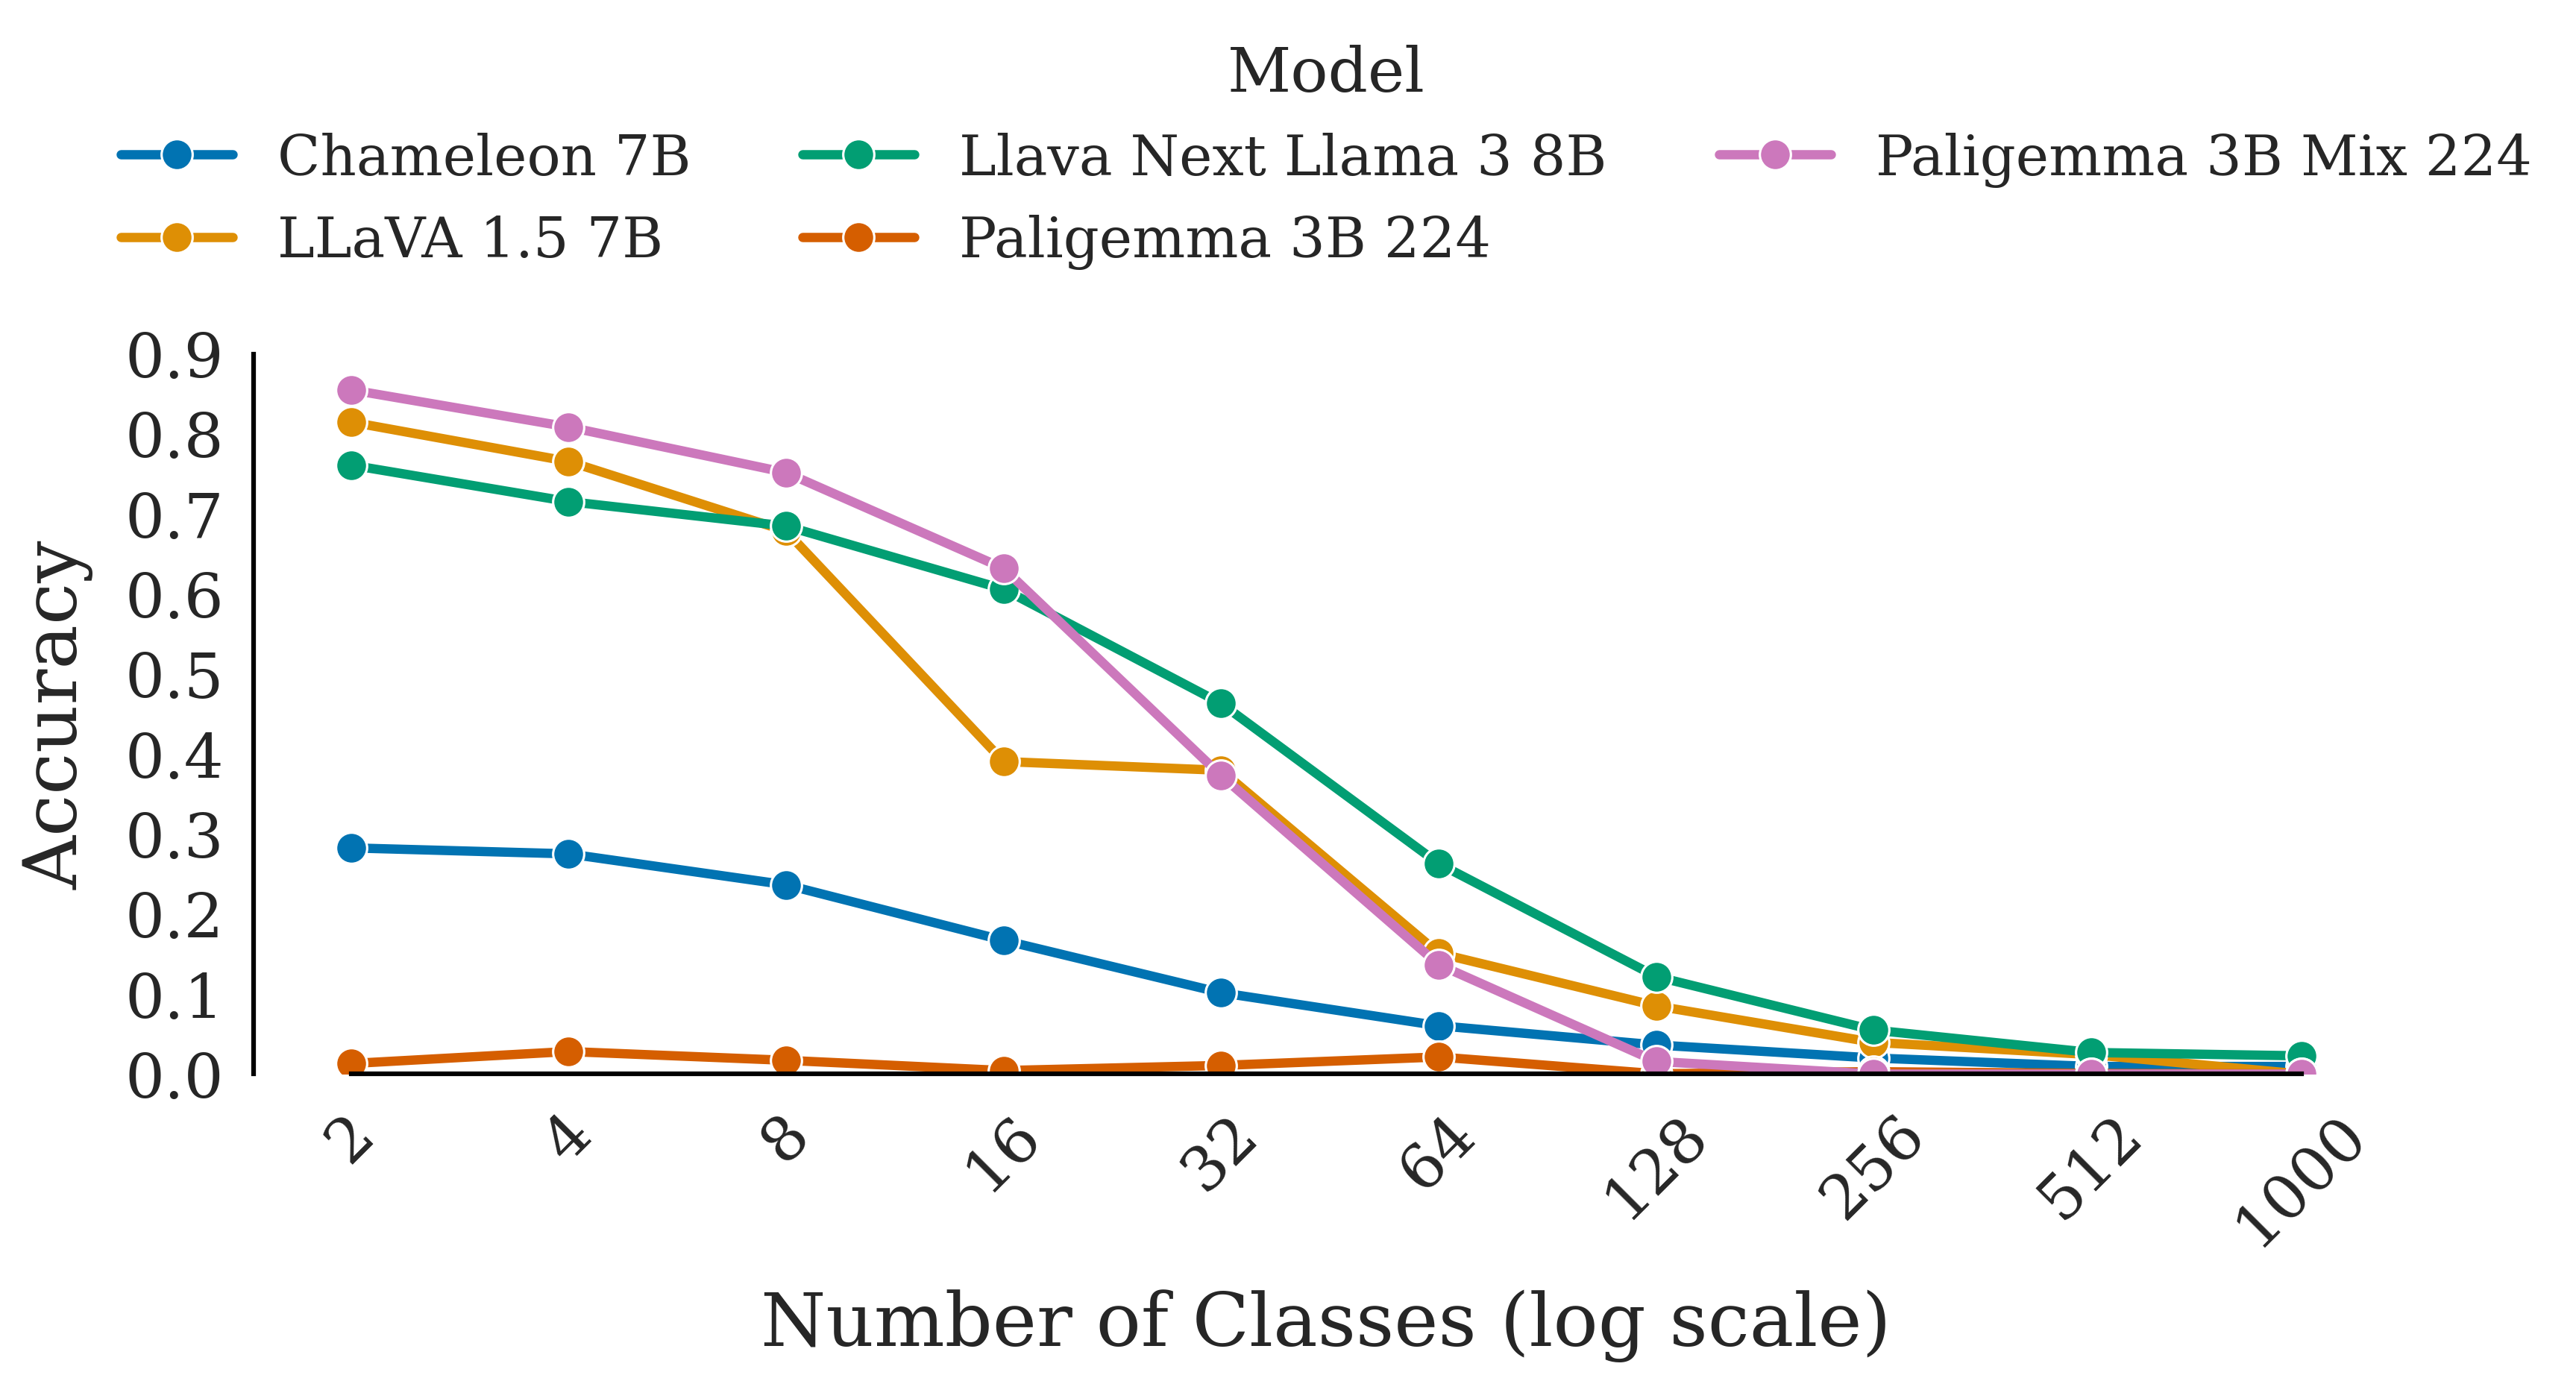

In [ ]:
# Extract the number of classes from benchmark_name
results['num_classes_prompt'] = results['benchmark_name'].str.extract(r'imagenet1k_(\d+)').astype(int)

# Group by model_name and num_classes_prompt, and compute average correctness
performance_by_class = results.groupby(['model_name', 'num_classes_prompt'])['correctness'].mean().reset_index()
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Custom font sizes and styling
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 20
LEGEND_FONT_SIZE = 20
TITLE_FONT_SIZE = 26
LINE_WIDTH = 3
MARKER_SIZE = 10

# Apply consistent theme and serif font
sns.set_theme(style="white", font_scale=1.5)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# Create figure
plt.figure(figsize=(12, 8), dpi=300)

# Colorblind-friendly palette
palette = sns.color_palette("colorblind")

# Line plot
ax = sns.lineplot(
    data=performance_by_class,
    x='num_classes_prompt',
    y='correctness',
    hue='model_name',
    marker='o',
    markersize=MARKER_SIZE,
    linewidth=LINE_WIDTH,
    palette=palette
)

# X-axis (log scale)
ax.set_xscale('log', base=2)
ax.set_xticks([2, 4, 8, 16, 32, 64, 128, 256, 512, 1000])
ax.set_xticklabels([2, 4, 8, 16, 32, 64, 128, 256, 512, 1000], rotation=45)
ax.xaxis.set_major_locator(ticker.FixedLocator([2, 4, 8, 16, 32, 64, 128, 256, 512, 1000]))

# Labels
ax.set_xlabel("Number of Classes (log scale)", fontsize=LABEL_FONT_SIZE, labelpad=10)
ax.set_ylabel("Accuracy", fontsize=LABEL_FONT_SIZE, labelpad=10)

# Title
# ax.set_title("ImageNet: Model Performance vs. Number of Classes", fontsize=TITLE_FONT_SIZE, pad=20)

# Ticks styling
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE, width=1.5, length=6)

# Y-axis
ax.set_ylim(0, 0.9)
ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ax.set_yticklabels([f"{x:.1f}" for x in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]])

# Legend
# Legend at the top without border
ax.legend(
    title='Model',
    title_fontsize=LEGEND_FONT_SIZE,
    fontsize=LEGEND_FONT_SIZE - 2,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.5),
    ncol=3  # Adjust column count as needed
)


# Remove grid and spines
sns.despine(trim=True)
ax.grid(False)

# Tight layout
plt.tight_layout()
# plt.savefig("imagenet_accuracy_vs_class_count.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [3]:
import pandas as pd

from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = [
    'llava_1_5_7b',
    'llava_next_llama_8b',
    'chameleon_7b',
    'paligemma_3b_224',
    'paligemma_3b_mix_224'
]

benchmarks = [
    # 'fungi_tastic_2025',
    'fungi_tastic_2025_num_classes_2',
    'fungi_tastic_2025_num_classes_4',
    'fungi_tastic_2025_num_classes_8',
    'fungi_tastic_2025_num_classes_16', 
    'fungi_tastic_2025_num_classes_32',
    'fungi_tastic_2025_num_classes_64',
    'fungi_tastic_2025_num_classes_128',
    'fungi_tastic_2025_num_classes_256',
    'fungi_tastic_2025_num_classes_512',
]

outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = {
    'llava_1_5_7b': 'LLaVA 1.5 7B',
    'llava_next_llama_8b': 'Llava Next Llama 3 8B',
    'chameleon_7b': 'Chameleon 7B',
    'paligemma_3b_224': 'Paligemma 3B 224',
    'paligemma_3b_mix_224': 'Paligemma 3B Mix 224',
}
results['model_name'] = results["model_name"].map(model_mappings)

/tmp/ipykernel_3451477/1614225017.py:33: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.lineplot(


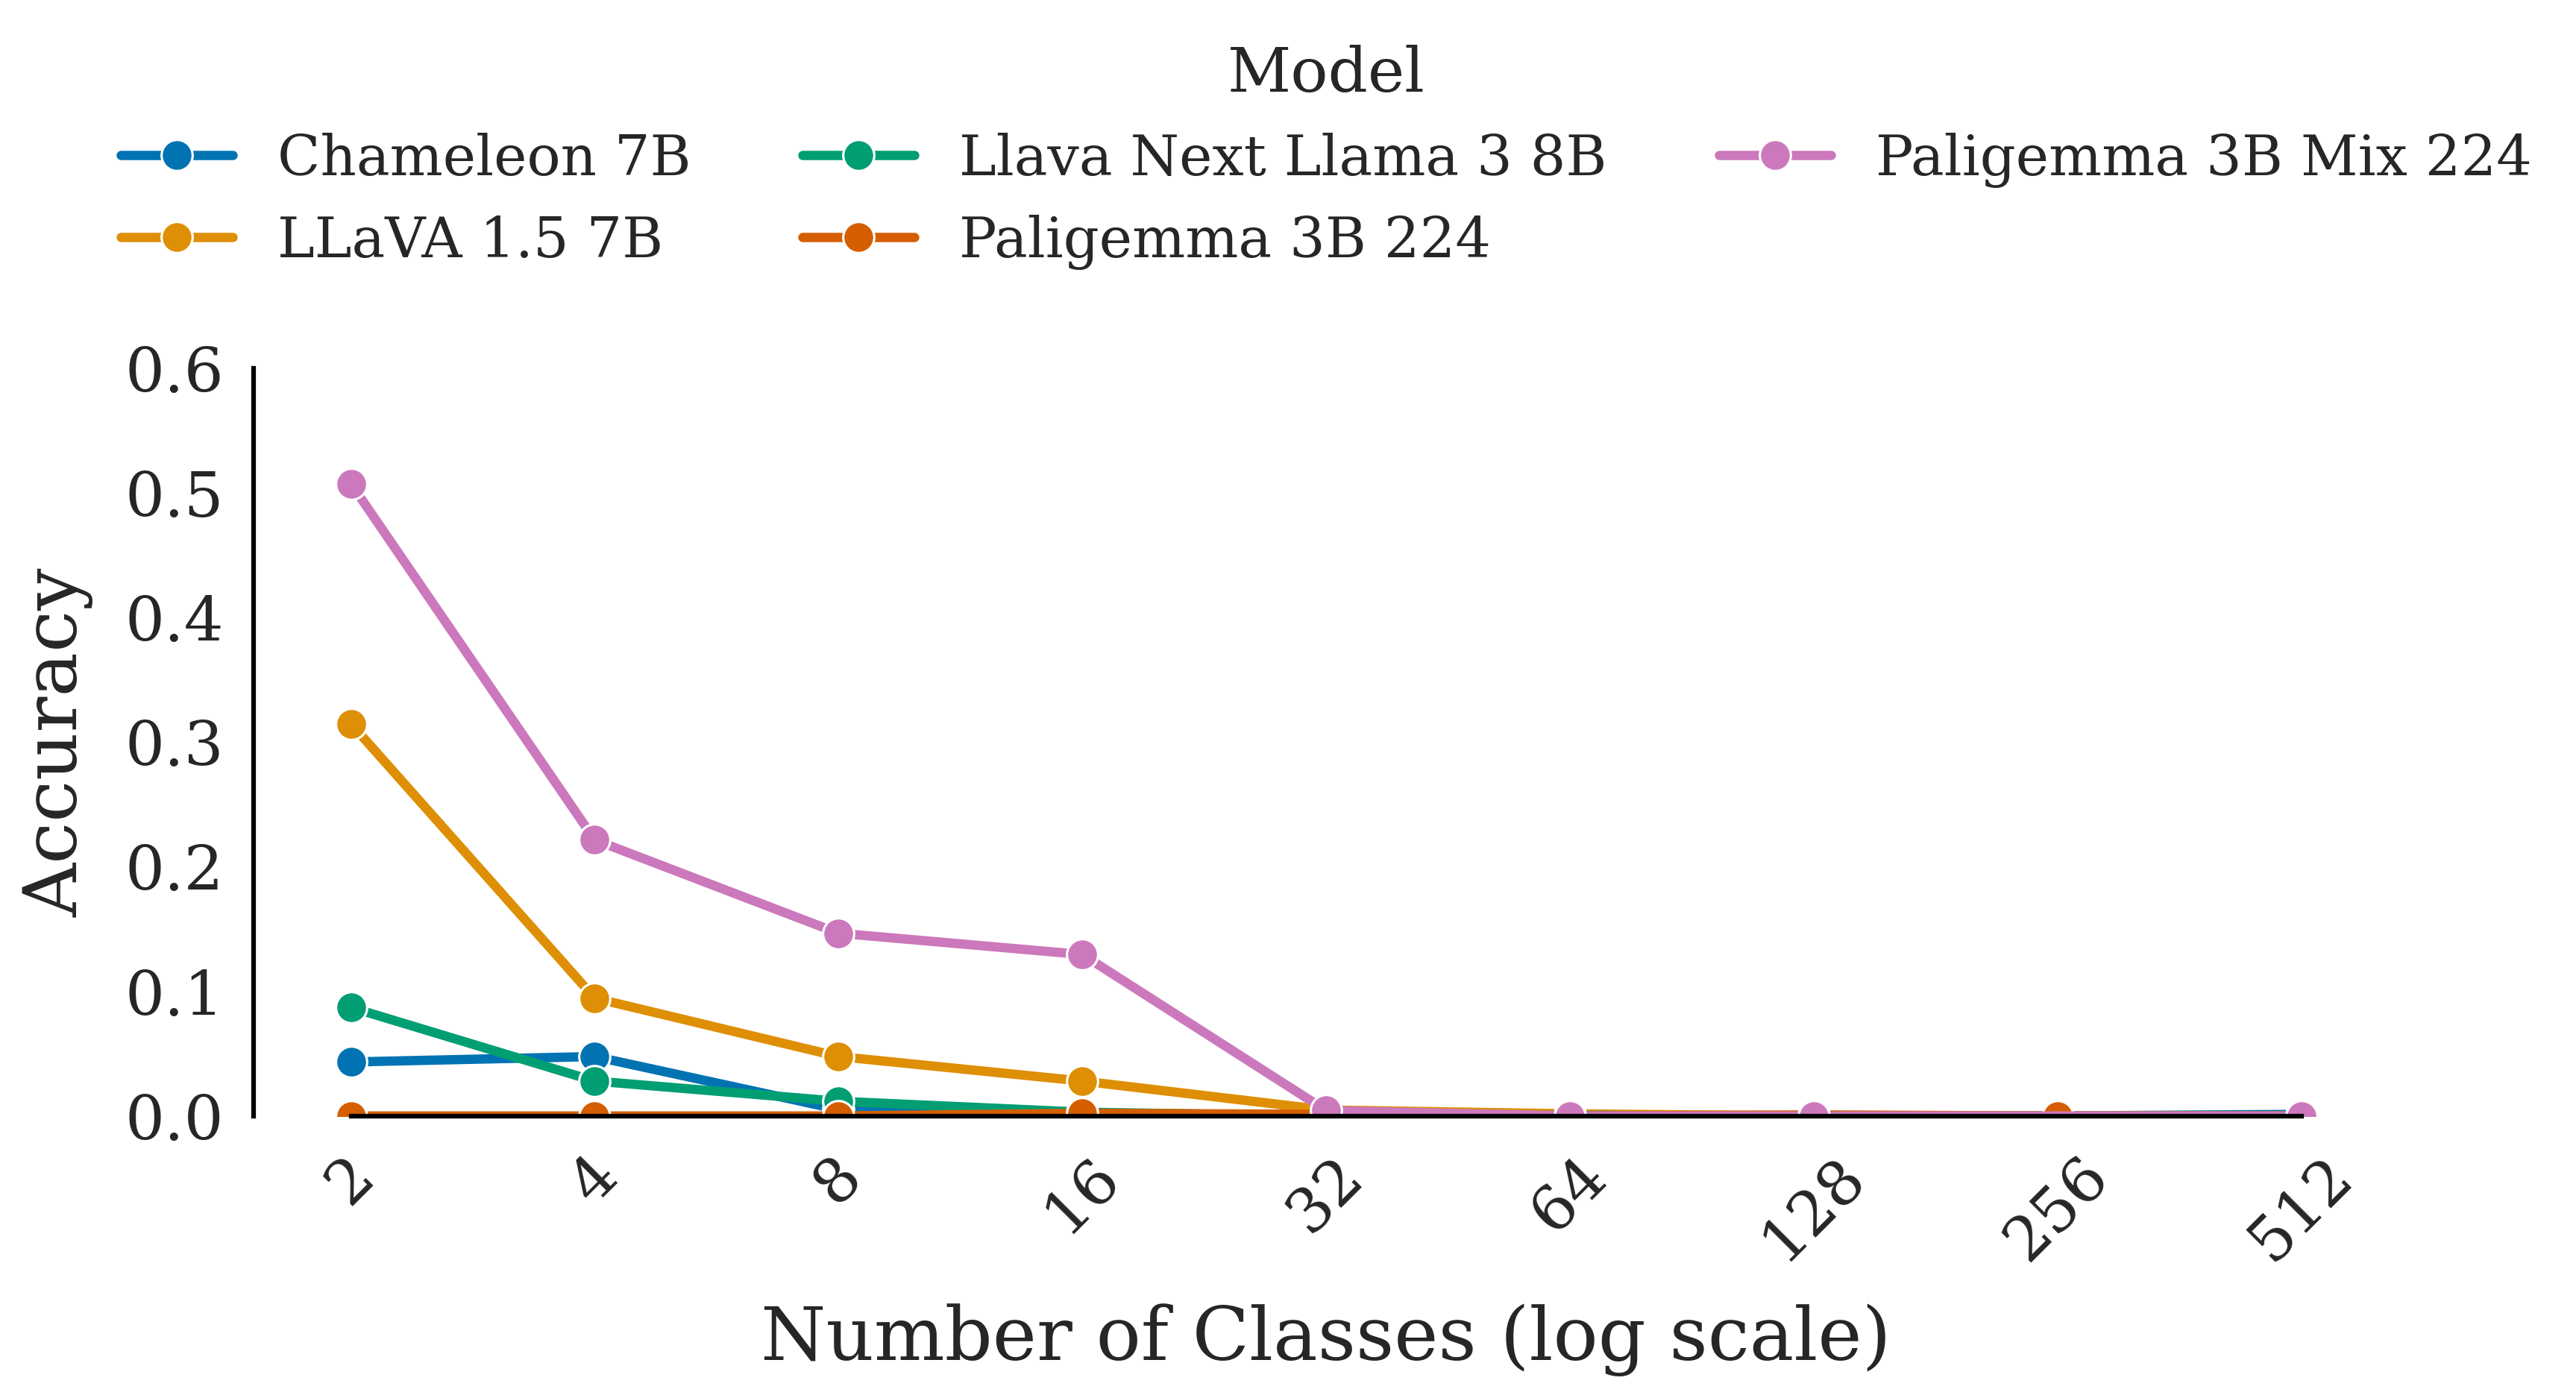

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Extract num_classes if not already present
if 'num_classes' not in results.columns:
    results['num_classes'] = results['benchmark_name'].apply(
        lambda x: int(x.split('_')[-1]) if 'num_classes' in x else 5
    )

# Group and compute mean performance
performance_by_class = results.groupby(['model_name', 'num_classes'])['correctness'].mean().reset_index()

# Styling parameters
LABEL_FONT_SIZE = 24
TICK_FONT_SIZE = 20
LEGEND_FONT_SIZE = 20
TITLE_FONT_SIZE = 26
LINE_WIDTH = 3
MARKER_SIZE = 10

# Theme and font
sns.set_theme(style="white", font_scale=1.5)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['axes.edgecolor'] = 'black'

# Create figure
plt.figure(figsize=(12, 8), dpi=300)

# Line plot
palette = sns.color_palette("colorblind")
ax = sns.lineplot(
    data=performance_by_class,
    x='num_classes',
    y='correctness',
    hue='model_name',
    marker='o',
    markersize=MARKER_SIZE,
    linewidth=LINE_WIDTH,
    palette=palette
)

# X-axis in log scale
ax.set_xscale('log', base=2)
unique_num_classes = sorted(performance_by_class['num_classes'].unique())
ax.set_xticks(unique_num_classes)
ax.set_xticklabels(unique_num_classes, rotation=45)

# Axis labels
ax.set_xlabel("Number of Classes (log scale)", fontsize=LABEL_FONT_SIZE, labelpad=10)
ax.set_ylabel("Accuracy", fontsize=LABEL_FONT_SIZE, labelpad=10)

# Title
# ax.set_title("Fungi-tastic (570 total classes): Model Performance vs. Number of Classes",
#              fontsize=TITLE_FONT_SIZE, pad=20)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE, width=1.5, length=6)

# Y-axis
ax.set_ylim(0, 0.6)
ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
ax.set_yticklabels([f"{x:.1f}" for x in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]])

# Legend on top, no border
ax.legend(
    title='Model',
    title_fontsize=LEGEND_FONT_SIZE,
    fontsize=LEGEND_FONT_SIZE - 2,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.5),
    ncol=3
)

# No grid, no spines
sns.despine(trim=True)
ax.grid(False)

# Layout and export
plt.tight_layout()
plt.savefig("fungi_tastic_performance_vs_classes.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [5]:
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = [    'paligemma_3b_224',
    'paligemma_3b_mix_224']
benchmarks = ['fungi_tastic_2025', 'imagenet1k']
outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
# model_mappings = get_model_mappings('name')
model_mappings = {
    'paligemma_3b_224': 'Paligemma 3B 224',
    'paligemma_3b_mix_224': 'Paligemma 3B Mix 224',
}
results['model_name'] = results["model_name"].map(model_mappings)
mapping = {
    'imagenet1k': 'ImageNet',
    'fungi_tastic_2025': 'Fungi-Tastic 2025'
}
results['benchmark_name'] = results["benchmark_name"].map(mapping)

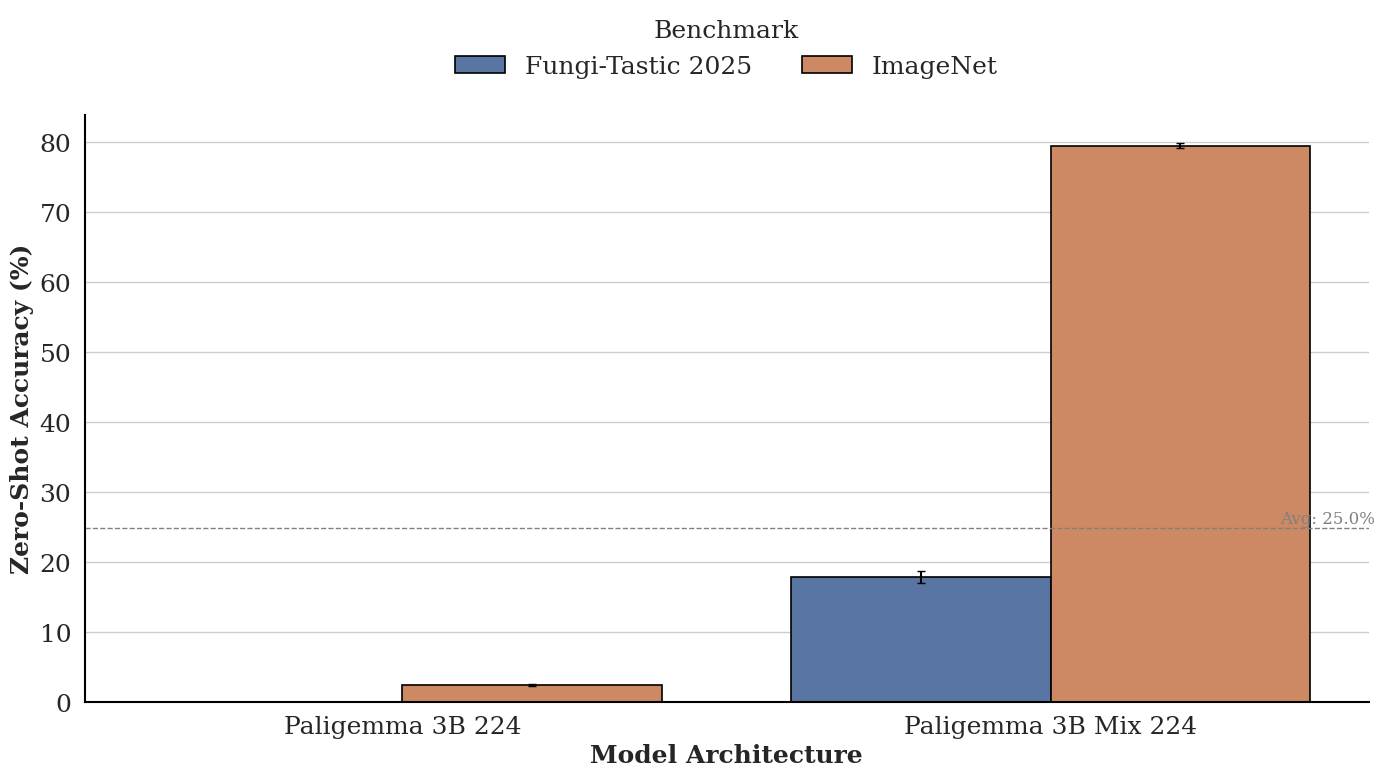

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute mean and SEM
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean().reset_index()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem().reset_index()

# Merge mean and SEM
model_data = pd.merge(df_mean, df_sem, on=["model_name", "benchmark_name"], suffixes=('', '_sem'))
model_data['performance'] = model_data['correctness'] * 100
model_data['sem'] = model_data['correctness_sem'] * 100

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 18
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': TICK_FONT_SIZE,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Barplot
ax = sns.barplot(
    data=model_data,
    x='model_name',
    y='performance',
    hue='benchmark_name',
    edgecolor='black',
    linewidth=1.2
)

# Add error bars
for i, (x, row) in enumerate(model_data.iterrows()):
    x_pos = ax.get_xticks()[model_data['model_name'].unique().tolist().index(row['model_name'])]
    offset = -0.2 if row['benchmark_name'] == model_data['benchmark_name'].unique()[0] else 0.2
    plt.errorbar(x_pos + offset, row['performance'], yerr=row['sem'], fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
# ax.set_title('Performance on Fungi-Tastic 2025', fontsize=TITLE_FONT_SIZE, weight='bold')

# Add average line
avg_performance = model_data['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(model_data['model_name'].unique()) - 0.5, avg_performance + 0.5,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Legend & layout
# Legend on top, larger font, no border
ax.legend(
    title='Benchmark',
    title_fontsize=LABEL_FONT_SIZE,
    fontsize=LABEL_FONT_SIZE,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.2),
    ncol=len(model_data['benchmark_name'].unique()),
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd

# from eval_vlm.datasets_zoo.registry import list_datasets
from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

models = ['llama_4_scout', 'llama_4_scout_instruct']
benchmarks = ['fungi_tastic_2025', 'imagenet1k']
outputhandler = OutputHandler(output_dir='/research/haider/.cache/unibench/outputs')

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
# model_mappings = get_model_mappings('name')
model_mappings = {
    'llama_4_scout': 'Llama 4 Scout',
    'llama_4_scout_instruct': 'Llama 4 Scout Instruct'
}
results['model_name'] = results["model_name"].map(model_mappings)
mapping = {
    'imagenet1k': 'ImageNet',
    'fungi_tastic_2025': 'Fungi-Tastic 2025'
}
results['benchmark_name'] = results["benchmark_name"].map(mapping)

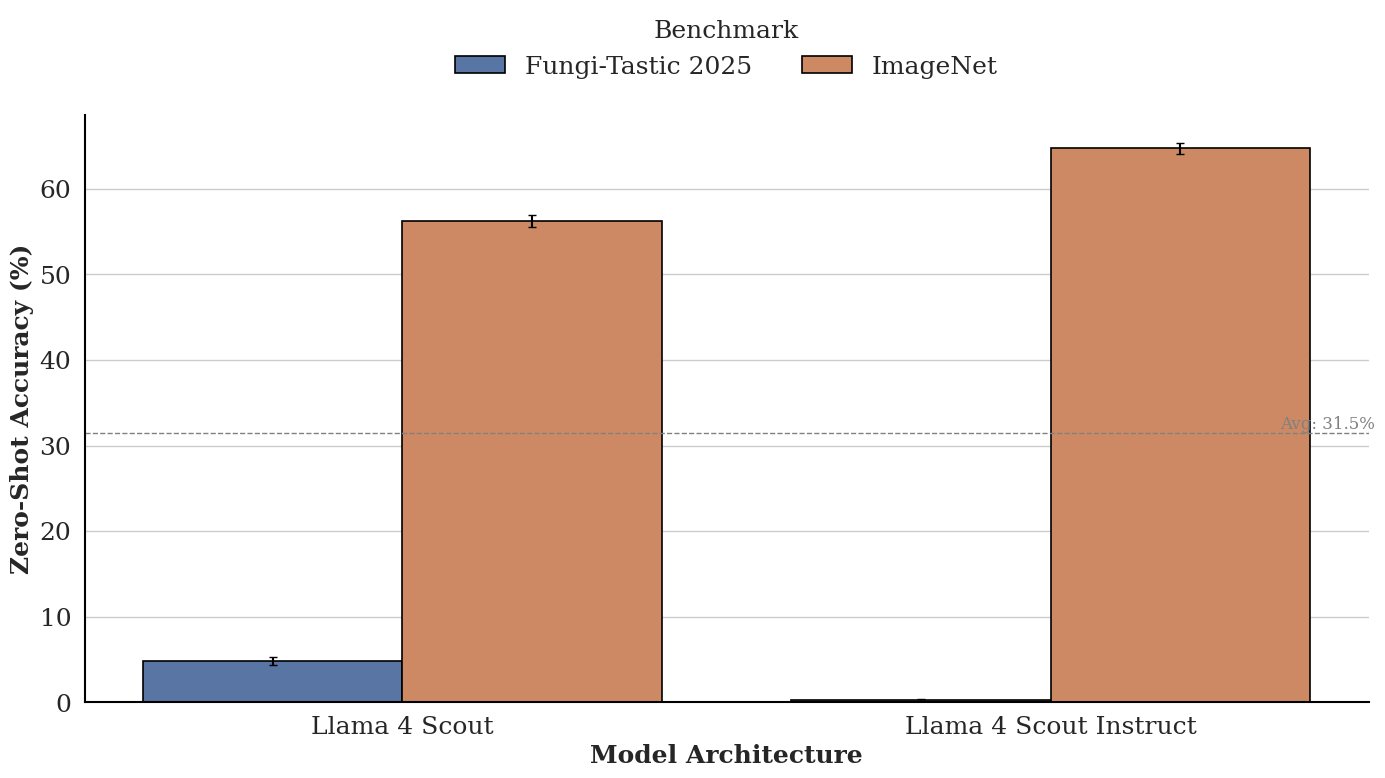

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Compute mean and SEM
df_mean = results.groupby(["model_name", "benchmark_name"]).correctness.mean().reset_index()
df_sem = results.groupby(["model_name", "benchmark_name"]).correctness.sem().reset_index()

# Merge mean and SEM
model_data = pd.merge(df_mean, df_sem, on=["model_name", "benchmark_name"], suffixes=('', '_sem'))
model_data['performance'] = model_data['correctness'] * 100
model_data['sem'] = model_data['correctness_sem'] * 100

# --- Styling ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 18
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': LABEL_FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize': TICK_FONT_SIZE,
    'ytick.labelsize': TICK_FONT_SIZE,
    'axes.linewidth': 1.5,
    'axes.edgecolor': 'black'
})

# Create figure
plt.figure(figsize=(14, 8))

# Barplot
ax = sns.barplot(
    data=model_data,
    x='model_name',
    y='performance',
    hue='benchmark_name',
    edgecolor='black',
    linewidth=1.2
)

# Add error bars
for i, (x, row) in enumerate(model_data.iterrows()):
    x_pos = ax.get_xticks()[model_data['model_name'].unique().tolist().index(row['model_name'])]
    offset = -0.2 if row['benchmark_name'] == model_data['benchmark_name'].unique()[0] else 0.2
    plt.errorbar(x_pos + offset, row['performance'], yerr=row['sem'], fmt='none', color='black',
                 capsize=3, elinewidth=1.5)

# Labels
ax.set_xlabel('Model Architecture')
ax.set_ylabel('Zero-Shot Accuracy (%)')
# ax.set_title('Performance on Fungi-Tastic 2025', fontsize=TITLE_FONT_SIZE, weight='bold')

# Add average line
avg_performance = model_data['performance'].mean()
ax.axhline(avg_performance, linestyle='--', color='gray', linewidth=1)
ax.text(len(model_data['model_name'].unique()) - 0.5, avg_performance + 0.5,
        f'Avg: {avg_performance:.1f}%', fontsize=ANNOTATION_FONT_SIZE,
        color='gray', ha='right')

# Legend & layout
# Legend on top, larger font, no border
ax.legend(
    title='Benchmark',
    title_fontsize=LABEL_FONT_SIZE,
    fontsize=LABEL_FONT_SIZE,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.2),
    ncol=len(model_data['benchmark_name'].unique()),
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()
